In [1]:
# Cell 1 — Imports  (pyarrow MUST be first: Windows DLL fix)
import pyarrow
import transformers
import torch
import os, sys, math
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm

print(f'torch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch 2.5.1+cu121 | CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# Cell 2 — Config
MODEL_NAME       = 'gpt2'
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES        = 100
NLDD_THRESHOLD   = 0.1
THRESHOLD_FACTOR = 0.5
N_BINS           = 10
OUT_DIR          = '../outputs'

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Model: {MODEL_NAME}  |  Device: {DEVICE}')
print(f'Samples: {N_SAMPLES}  |  NLDD threshold: {NLDD_THRESHOLD}')

Model: gpt2  |  Device: cuda
Samples: 100  |  NLDD threshold: 0.1


In [3]:
# Cell 3 — Load GPT-2 via TransformerLens
from src.utils.model_loader import get_model

print(f'Loading {MODEL_NAME} ...')
model = get_model(MODEL_NAME, device=DEVICE)
print(f'Loaded  layers={model.cfg.n_layers}  d_model={model.cfg.d_model}  vocab={model.cfg.d_vocab}')

Loading gpt2 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
Loaded  layers=12  d_model=768  vocab=50257


In [4]:
# Cell 4 — Load 20 GSM8K samples
from data.dataset_loader import load_gsm8k

samples = load_gsm8k(split='test', max_samples=N_SAMPLES)
print(f'Loaded {len(samples)} samples')
s0 = samples[0]
print('Example Q:', s0['question'][:100])
print(f'Steps ({len(s0["steps"])}): {s0["steps"][0][:80]}')

Loaded 100 samples
Example Q: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for 
Steps (3): Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.


In [5]:
# Cell 5 — Define run_experiment_for_sample
# Uses generate_faithfulness_labels (NLDD per step) + compute_all_metrics (RSA, TAS)
from src.probing.faithfulness_detector import generate_faithfulness_labels, corrupt_step
from src.probing.cot_probe import extract_cot_activations
from src.utils.metrics import compute_all_metrics

def run_experiment_for_sample(sample, model):
    """NLDD + RSA + TAS analysis for one GSM8K sample."""
    question, steps = sample['question'], sample['steps']
    if len(steps) < 2:
        return None
    prompt = 'Q: ' + question + ' A: ' + ' '.join(steps)
    try:
        labels = generate_faithfulness_labels(
            model, prompt, steps,
            strategy='number_perturbation', nldd_threshold=NLDD_THRESHOLD)
    except Exception as exc:
        print(f'  skip ({type(exc).__name__})')
        return None
    nldd_scores = [nldd for _, _, nldd in labels]
    # Activation-level analysis: clean vs step-0 corruption
    clean_acts = extract_cot_activations(model, prompt)
    c0       = corrupt_step(steps[0], strategy='number_perturbation', seed=0)
    c_prompt = prompt.replace(steps[0], c0, 1)
    c_acts   = extract_cot_activations(model, c_prompt)
    with torch.no_grad():
        lp_c = float(torch.log_softmax(model(model.to_tokens(prompt))[0, -1], dim=-1).max())
        lp_r = float(torch.log_softmax(model(model.to_tokens(c_prompt))[0, -1], dim=-1).max())
    metrics = compute_all_metrics(clean_acts, c_acts, lp_c, lp_r)
    return {'nldd_scores': nldd_scores, 'rsa': metrics['rsa'],
            'tas': metrics['tas'], 'n_steps': len(steps)}

print('run_experiment_for_sample defined.')

run_experiment_for_sample defined.


In [6]:
# Cell 6 — Run batch experiment
results, n_skip = [], 0
for sample in tqdm(samples, desc='Analysing GSM8K'):
    r = run_experiment_for_sample(sample, model)
    if r is not None:
        results.append(r)
    else:
        n_skip += 1

print(f'Valid: {len(results)}/{N_SAMPLES}  |  skipped: {n_skip}')
if results:
    sc = [r['n_steps'] for r in results]
    print(f'Steps per sample — min:{min(sc)}  max:{max(sc)}  mean:{np.mean(sc):.1f}')

Analysing GSM8K:   0%|          | 0/100 [00:00<?, ?it/s]

Analysing GSM8K:   1%|          | 1/100 [00:00<00:35,  2.78it/s]

Analysing GSM8K:   2%|▏         | 2/100 [00:00<00:22,  4.26it/s]

Analysing GSM8K:   3%|▎         | 3/100 [00:00<00:21,  4.51it/s]

Analysing GSM8K:   4%|▍         | 4/100 [00:00<00:18,  5.23it/s]

...

Analysing GSM8K:  98%|█████████▊| 98/100 [00:18<00:00,  5.78it/s]

Analysing GSM8K:  99%|█████████▉| 99/100 [00:18<00:00,  6.00it/s]

Analysing GSM8K: 100%|██████████| 100/100 [00:19<00:00,  5.75it/s]

Analysing GSM8K: 100%|██████████| 100/100 [00:19<00:00,  5.25it/s]

Valid: 100/100  |  skipped: 0
Steps per sample — min:3  max:8  mean:4.4


In [7]:
# Cell 7 — Normalise NLDD to relative position [0, 1] and find k* per sample
from src.pipeline.closed_loop import find_reasoning_horizon

normalised_nldd  = np.zeros((len(results), N_BINS))
k_star_positions = []

for i, r in enumerate(results):
    scores = np.array(r['nldd_scores'], dtype=float)
    n      = len(scores)
    x_orig = np.linspace(0, 1, max(n, 2))
    x_new  = np.linspace(0, 1, N_BINS)
    padded = np.pad(scores, (0, max(0, 2 - n)), 'edge')
    normalised_nldd[i] = np.interp(x_new, x_orig, padded)
    k = find_reasoning_horizon(r['nldd_scores'], threshold_factor=THRESHOLD_FACTOR)
    k_star_positions.append(k / max(1, n - 1))

mean_nldd   = normalised_nldd.mean(axis=0)
std_nldd    = normalised_nldd.std(axis=0)
mean_k_star = float(np.mean(k_star_positions))
print(f'Mean k* (normalised): {mean_k_star:.3f}  ({mean_k_star*100:.0f}% through chain)')

Mean k* (normalised): 0.169  (17% through chain)


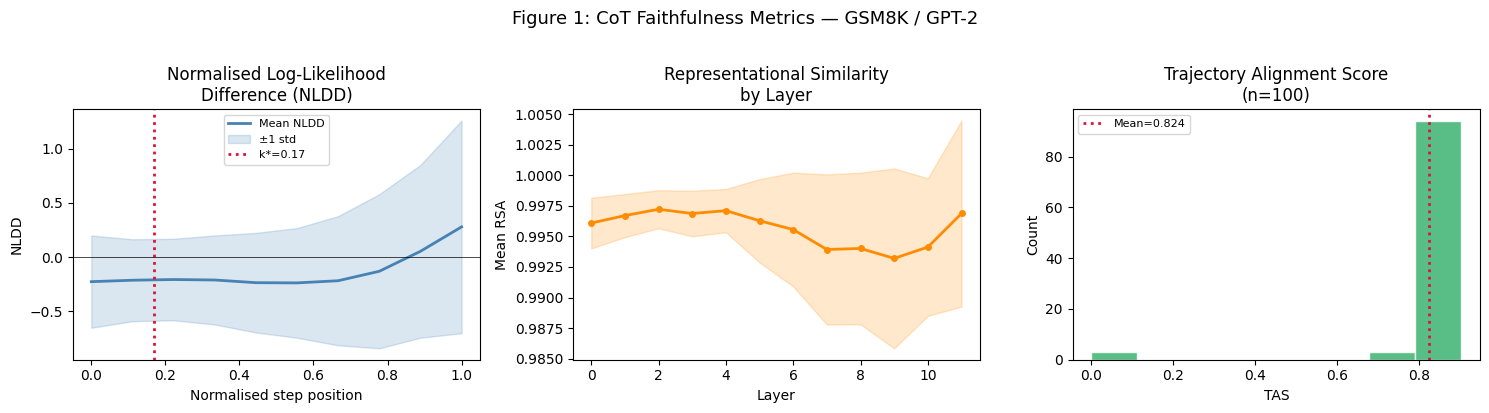

Saved -> outputs/figure1_baseline.png


In [8]:
# Cell 8 — Figure 1: NLDD + RSA + TAS subplots with k* marked
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_bins = np.linspace(0, 1, N_BINS)

# Subplot 1 — NLDD by normalised step position
ax = axes[0]
ax.plot(x_bins, mean_nldd, color='steelblue', lw=2, label='Mean NLDD')
ax.fill_between(x_bins, mean_nldd - std_nldd, mean_nldd + std_nldd,
                color='steelblue', alpha=0.2, label='±1 std')
ax.axvline(mean_k_star, color='crimson', ls=':', lw=2, label=f'k*={mean_k_star:.2f}')
ax.axhline(0, color='black', lw=0.5)
ax.set(xlabel='Normalised step position', ylabel='NLDD',
       title='Normalised Log-Likelihood\nDifference (NLDD)')
ax.legend(fontsize=8)

# Subplot 2 — RSA by layer
rsa_by_layer = {}
for r in results:
    for l, v in r['rsa'].items():
        rsa_by_layer.setdefault(l, []).append(v)
layers   = sorted(rsa_by_layer)
rsa_mean = [np.mean(rsa_by_layer[l]) for l in layers]
rsa_std  = [np.std(rsa_by_layer[l])  for l in layers]
ax = axes[1]
ax.plot(layers, rsa_mean, color='darkorange', lw=2, marker='o', ms=4)
ax.fill_between(layers,
                [m - s for m, s in zip(rsa_mean, rsa_std)],
                [m + s for m, s in zip(rsa_mean, rsa_std)],
                color='darkorange', alpha=0.2)
ax.set(xlabel='Layer', ylabel='Mean RSA', title='Representational Similarity\nby Layer')

# Subplot 3 — TAS distribution
tas_vals = [r['tas'] for r in results if not math.isnan(r['tas'])]
ax = axes[2]
ax.hist(tas_vals, bins=8, color='mediumseagreen', edgecolor='white', alpha=0.85)
mu_tas = float(np.mean(tas_vals)) if tas_vals else 0.0
ax.axvline(mu_tas, color='crimson', ls=':', lw=2, label=f'Mean={mu_tas:.3f}')
ax.set(xlabel='TAS', ylabel='Count',
       title=f'Trajectory Alignment Score\n(n={len(tas_vals)})')
ax.legend(fontsize=8)

fig.suptitle('Figure 1: CoT Faithfulness Metrics — GSM8K / GPT-2', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'figure1_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/figure1_baseline.png')

In [9]:
# Cell 9 — Observation table
all_nldd   = [s for r in results for s in r['nldd_scores']]
faith_nldd = [s for s in all_nldd if s >  NLDD_THRESHOLD]
unfai_nldd = [s for s in all_nldd if s <= NLDD_THRESHOLD]

obs = pd.DataFrame({
    'Metric': [
        'Mean NLDD (all steps)',
        'Mean NLDD (faithful steps)',
        'Mean NLDD (unfaithful steps)',
        'Faithful step fraction',
        'Mean RSA (all layers)',
        'Mean TAS',
        'Mean k* (normalised)',
        'Total steps analysed',
    ],
    'Value': [
        f'{np.mean(all_nldd):.4f}'   if all_nldd   else 'n/a',
        f'{np.mean(faith_nldd):.4f}' if faith_nldd else 'n/a',
        f'{np.mean(unfai_nldd):.4f}' if unfai_nldd else 'n/a',
        f'{len(faith_nldd)/max(1,len(all_nldd)):.1%}',
        f'{np.mean(rsa_mean):.4f}'   if rsa_mean   else 'n/a',
        f'{mu_tas:.4f}',
        f'{mean_k_star:.3f}',
        str(len(all_nldd)),
    ],
})
print(obs.to_string(index=False))

                      Metric   Value
       Mean NLDD (all steps) -0.1263
  Mean NLDD (faithful steps)  0.6308
Mean NLDD (unfaithful steps) -0.4215
      Faithful step fraction   28.1%
       Mean RSA (all layers)  0.9957
                    Mean TAS  0.8238
        Mean k* (normalised)   0.169
        Total steps analysed     442


In [10]:
# Cell 10
print('Notebook 01 complete')

Notebook 01 complete
